In [17]:
import pandas as pd

# Manejo de Tipo de Datos `datetime`

En el ecosistema de Pandas, el manejo de series temporales se apoya principalmente en el tipo de datos `datetime`. Pandas utiliza una implementación basada en NumPy que permite almacenar fechas y horas con una precisión de nanosegundos. Esta estructura es la que permite que sea extremadamente eficiente al procesar millones de registros, facilitando tareas como el filtrado por rangos, el desplazamiento temporal (shifting) y hasta la visualización.

Veamos dos formas de pasar a `datetime` una columna.

### OJO AL PIOJO!
En ningún momento nos dijeron que la columna `Date` era única, habría que hacer el chequeo de antemano...

## Primera Forma
Directamente al leer el CSV:
- Podemos pasarle el formato que tiene las fechas en el archivo con `date_format` y lo va a aplicar a todas las columnas, transformando a `datetime` la que pueda aplicar exitosamente.
- También está la variable `infer_datetime_format` que pueden setear a True, pero no es recomendable ir por este lado (mucho poder de cómputo).

En este caso, establecemos la columna Date como índice y le damos el date_format, lo que resulta en que el Index va a ser del tipo `DatetimeIndex`.

In [18]:
crashes_data = pd.read_csv("Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv", encoding="latin-1", index_col="Date", date_format="%m/%d/%Y")
crashes_data.head()

,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
Date,,,,,,,,,,,,,,,,
1908-09-17,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1909-09-07,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
1912-07-12,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
1913-08-06,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...
1913-09-09,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...


In [19]:
crashes_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4998 entries, 1908-09-17 to 2023-11-01
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Time                   3486 non-null   object 
 1   Location               4994 non-null   object 
 2   Operator               4988 non-null   object 
 3   Flight #               1329 non-null   object 
 4   Route                  4221 non-null   object 
 5   AC Type                4983 non-null   object 
 6   Registration           4724 non-null   object 
 7   cn/ln                  4330 non-null   object 
 8   Aboard                 4980 non-null   float64
 9   Aboard Passangers      4769 non-null   float64
 10  Aboard Crew            4772 non-null   float64
 11  Fatalities             4990 non-null   float64
 12  Fatalities Passangers  4756 non-null   float64
 13  Fatalities Crew        4757 non-null   float64
 14  Ground                 4956 non-null  

## Segunda Forma: Función `to_datetime`

Pandas posee una función que podemos utilizar para convertir una columna al tipo `datetime`. Realicemos la conversión desde una nueva lectura del archivo CSV. 

In [20]:
crashes_data = pd.read_csv("Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv", encoding="latin-1")
crashes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   4998 non-null   object 
 1   Time                   3486 non-null   object 
 2   Location               4994 non-null   object 
 3   Operator               4988 non-null   object 
 4   Flight #               1329 non-null   object 
 5   Route                  4221 non-null   object 
 6   AC Type                4983 non-null   object 
 7   Registration           4724 non-null   object 
 8   cn/ln                  4330 non-null   object 
 9   Aboard                 4980 non-null   float64
 10  Aboard Passangers      4769 non-null   float64
 11  Aboard Crew            4772 non-null   float64
 12  Fatalities             4990 non-null   float64
 13  Fatalities Passangers  4756 non-null   float64
 14  Fatalities Crew        4757 non-null   float64
 15  Grou

In [21]:
crashes_data["Date"] = pd.to_datetime(crashes_data["Date"]) # esto a veces funciona de una, a veces deberemos pasar nosotr@s el formato que pensamos que tiene

In [22]:
crashes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   4998 non-null   datetime64[ns]
 1   Time                   3486 non-null   object        
 2   Location               4994 non-null   object        
 3   Operator               4988 non-null   object        
 4   Flight #               1329 non-null   object        
 5   Route                  4221 non-null   object        
 6   AC Type                4983 non-null   object        
 7   Registration           4724 non-null   object        
 8   cn/ln                  4330 non-null   object        
 9   Aboard                 4980 non-null   float64       
 10  Aboard Passangers      4769 non-null   float64       
 11  Aboard Crew            4772 non-null   float64       
 12  Fatalities             4990 non-null   float64       
 13  Fat

# Operar con `datetime`

La magia de este tipo de dato reside en su capacidad para "descomponer" la información: una vez que una columna tiene el formato correcto, podemos acceder a sus propiedades (como el año, mes, día o incluso el nombre del día de la semana) utilizando el accesor .dt.

Por ejemplo, si tenemos una serie `df['Date']`, la operación `df['Date'].dt.month` nos devolverá el mes de cada registro de forma instantánea sin necesidad de usar bucles for.

In [23]:
crashes_data["Date"].dt.month

0        9
1        9
2        7
3        8
4        9
        ..
4993    11
4994     1
4995     9
4996    10
4997    11
Name: Date, Length: 4998, dtype: int32

In [24]:
crashes_data["Date_month"] = crashes_data["Date"].dt.month

<Axes: xlabel='Date_month'>

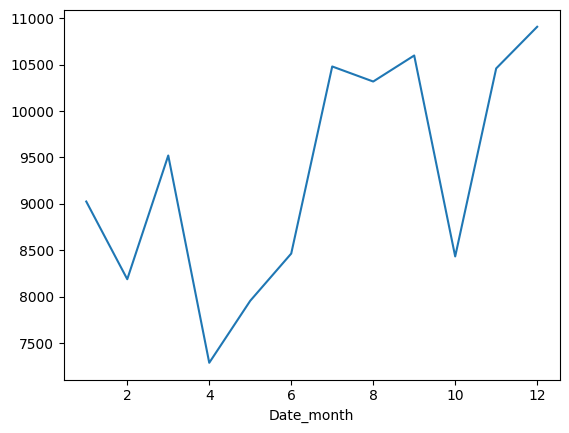

In [25]:
crashes_data.groupby("Date_month")["Fatalities"].sum().plot()